In [14]:
import torch
import numpy as np
from torchvision import datasets
from torchvision.transforms import v2 as transforms
from torch.utils.data import DataLoader, random_split, Dataset

# Segédosztály a transzformációk különválasztásához Subset esetén
class ApplyTransform(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)


# Külön osztály a zaj-augmentációhoz
class NoiseAugmentation:
    def __init__(self, noise_type=None, **noise_params):
        """
        noise_type: 'gaussian', 'salt_pepper', 'poisson', vagy None
        noise_params: a zajtípushoz tartozó paraméterek (pl. mean, std, amount)
        """
        self.noise_type = noise_type
        self.noise_params = noise_params

    def __call__(self, tensor):
        if self.noise_type is None:
            return tensor

        if self.noise_type == 'gaussian':
            mean = self.noise_params.get('mean', 0.0)
            std = self.noise_params.get('std', 0.1)
            noise = torch.randn_like(tensor) * std + mean
            return torch.clamp(tensor + noise, 0.0, 1.0)

        elif self.noise_type == 'salt_pepper':
            amount = self.noise_params.get('amount', 0.05)
            s_vs_p = self.noise_params.get('salt_vs_pepper', 0.5)
            noisy = tensor.clone()
            # Véletlenszerű mátrix a valószínűségekhez
            rand_matrix = torch.rand_like(tensor)
            # Só (fehér pixelek)
            noisy[rand_matrix < amount * s_vs_p] = 1.0
            # Bors (fekete pixelek)
            noisy[rand_matrix > 1.0 - amount * (1.0 - s_vs_p)] = 0.0
            return noisy

        elif self.noise_type == 'poisson':
            # A Poisson eloszlás gyakoriság alapú, így a 0-1 tartományt felskálázzuk
            # egy "rate" paraméterrel (pl. 255), rátesszük a zajt, majd visszaskálázzuk.
            scale = self.noise_params.get('scale', 255.0)
            noisy = torch.poisson(tensor * scale) / scale
            return torch.clamp(noisy, 0.0, 1.0)

        else:
            raise ValueError(f"Nem támogatott zaj típus: {self.noise_type}")


class DataManager:
    def __init__(self, dataset_name='cifar10', data_dir='./data', batch_size=100,
                 valid_split=0.2, num_workers=2, noise_type=None, noise_params=None):
        self.dataset_name = dataset_name.lower()
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.valid_split = valid_split
        self.num_workers = num_workers

        # Zaj paraméterek elmentése
        self.noise_type = noise_type
        self.noise_params = noise_params if noise_params is not None else {}

        self.datasets_dict = {
            'mnist': datasets.MNIST,
            'cifar10': datasets.CIFAR10,
            'cifar100': datasets.CIFAR100,
        }

        if self.dataset_name not in self.datasets_dict:
            raise ValueError(f"Nem támogatott adathalmaz: {self.dataset_name}")

        self.DatasetClass = self.datasets_dict[self.dataset_name]

    def _get_mean_std(self):
        """
        Adathalmaz-specifikus normalizációs értékek.
        Fontos: Az MNIST 1 csatornás, a többi 3 csatornás!
        """
        if self.dataset_name == 'mnist':
            return [0.1307], [0.3081]
        elif self.dataset_name == 'cifar10':
            return [0.4914, 0.4822, 0.4465], [0.2023, 0.1994, 0.2010]
        elif self.dataset_name == 'cifar100':
            return [0.5071, 0.4865, 0.4409], [0.2673, 0.2564, 0.2762]
        return [0.5, 0.5, 0.5], [0.5, 0.5, 0.5]

    def get_loaders(self):
        mean, std = self._get_mean_std()

        # A tréning során adjuk hozzá a zajt a 0-1 skálázás után, normalizáció előtt
        train_transform = transforms.Compose([
            transforms.ToImage(),
            transforms.ToDtype(torch.float32, scale=True),
            NoiseAugmentation(noise_type=self.noise_type, **self.noise_params),
            transforms.Normalize(mean=mean, std=std)
        ])

        # A validációnál és tesztnél NINCS zaj augmentáció
        test_transform = transforms.Compose([
            transforms.ToImage(),
            transforms.ToDtype(torch.float32, scale=True),
            transforms.Normalize(mean=mean, std=std)
        ])

        # Az alap adathalmazt transzformáció nélkül töltjük be a train/valid szétválasztáshoz
        full_train_set = self.DatasetClass(root=self.data_dir, train=True, download=True)
        test_set = self.DatasetClass(root=self.data_dir, train=False, download=True, transform=test_transform)

        valid_size = int(len(full_train_set) * self.valid_split)
        train_size = len(full_train_set) - valid_size

        # Logikailag helyes split fix seed-del
        train_subset, valid_subset = random_split(
            full_train_set, [train_size, valid_size],
            generator=torch.Generator().manual_seed(42)
        )

        # Itt alkalmazzuk külön a transzformációkat
        train_data = ApplyTransform(train_subset, transform=train_transform)
        valid_data = ApplyTransform(valid_subset, transform=test_transform)

        train_loader = DataLoader(train_data, batch_size=self.batch_size, shuffle=True, num_workers=self.num_workers)
        valid_loader = DataLoader(valid_data, batch_size=self.batch_size, shuffle=False, num_workers=self.num_workers)
        test_loader = DataLoader(test_set, batch_size=self.batch_size, shuffle=False, num_workers=self.num_workers)

        return train_loader, valid_loader, test_loader


Tanító halmaz mérete: 40000
Validációs halmaz mérete: 10000
Teszt halmaz mérete: 10000
Batchenkénti képek száma: 400
Képek dimenziója: torch.Size([100, 3, 32, 32]), Címkék: torch.Size([100])


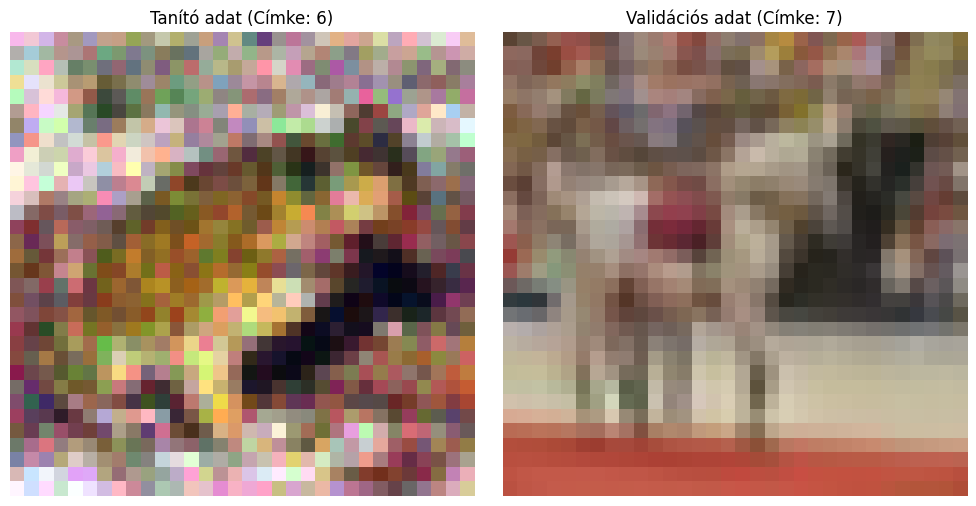

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import torch

#Adatok beolvasása, MNIST, CIFAR10, CIFAR100 és ImageNet közül lehet választani.
#-----------------------------------------------------------------------------------------------------------
# Gaussian zajjal
#data_manager = DataManager(dataset_name='cifar10', noise_type='gaussian', noise_params={'std': 0.08}) # std nagyobb --> nagyobb zaj
#-----------------------------------------------------------------------------------------------------------
# Só-bors zajjal
#data_manager = DataManager(dataset_name='cifar10', noise_type='salt_pepper', noise_params={'amount': 0.08}) # amount --> aránya az eltorított pixeleknek
#-----------------------------------------------------------------------------------------------------------
# Poisson zajjal
data_manager = DataManager(dataset_name='cifar10', noise_type='poisson', noise_params={'scale': 80.0}) # normalizált érték felskálázása --> kisebb érték = nagyobb zaj
#-----------------------------------------------------------------------------------------------------------

train_loader, valid_loader, test_loader = data_manager.get_loaders()

print(f"Tanító halmaz mérete: {len(train_loader.dataset)}")
print(f"Validációs halmaz mérete: {len(valid_loader.dataset)}")
print(f"Teszt halmaz mérete: {len(test_loader.dataset)}")

print(f"Batchenkénti képek száma: {len(train_loader)}")

# Egy batch lekérése teszteléshez
train_images, train_labels = next(iter(train_loader))
print(f"Képek dimenziója: {train_images.shape}, Címkék: {train_labels.shape}")

# --- KÉPEK MEGJELENÍTÉSE ---

def imshow(img, title, dataset_name='cifar10'):
    """Egy normalizált PyTorch tenzor megjelenítése Matplotlib segítségével."""
    # 1. CIFAR10 normalizációs értékek (a DataManager _get_mean_std függvényéből)
    if dataset_name == 'cifar10':
        mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
        std = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)
    else:
        # Ha más adathalmazt használsz, itt érdemes az ahhoz tartozó értékeket megadni
        mean = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
        std = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)

    # Visszanormalizálás: tensor * std + mean
    img = img.clone() * std + mean

    # Biztosítjuk, hogy az értékek 0.0 és 1.0 között maradjanak (a zaj miatt előfordulhat kilengés)
    img = torch.clamp(img, 0, 1)

    # 2. PyTorch (C, H, W) -> Numpy (H, W, C) konverzió
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(title)
    plt.axis('off')

# Validációs batch lekérése (hogy legyen összehasonlítási alapunk)
valid_images, valid_labels = next(iter(valid_loader))

# Ábra létrehozása (1 sor, 2 oszlop)
plt.figure(figsize=(10, 5))

# Első kép: Tanító adat (Ezen látszódnia kell a zajnak, ha be van állítva)
plt.subplot(1, 2, 1)
imshow(train_images[0], title=f"Tanító adat (Címke: {train_labels[0].item()})", dataset_name='cifar10')

# Második kép: Validációs adat (Ennek tisztának kell lennie, mert oda nem teszünk zajt)
plt.subplot(1, 2, 2)
imshow(valid_images[0], title=f"Validációs adat (Címke: {valid_labels[0].item()})", dataset_name='cifar10')

plt.tight_layout()
plt.show()

